In [2]:
import pandas as pd
import numpy as np
import joblib
import scipy.stats as stats
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [3]:
def calculate_spearman(dataset, model_name):

    # Configurações
    MODEL_PATH = f"../candidate_models/{dataset}/{model_name}.joblib"
    DATA_PATH = f"../data/meta/meta_processed/meta_proc_{dataset}.csv"

    # Carregamento 
    model = joblib.load(MODEL_PATH)
    df = pd.read_csv(DATA_PATH)

    try:
        # Separa em atributos preditivos e atributos alvo
        target_cols = ['F1 (macro averaged by label)', 'Model Size Log'] # alvo
        X = df.drop(columns=target_cols + ['Model Size'], errors='ignore') # preditivos
        y = df[target_cols] # alvo
    except KeyError as e:
        print(f"Erro nas colunas: {e}")
        exit()

    # Usa apenas o conjunto de teste, pois os modelos 
    # foram treinados no conjunto de treino
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Inferência
    preds = model.predict(X_test) # faz a inferência

    # Caso retorne 2D (R2 e model size log) utiliza apenas R2
    y_pred_f1 = preds[:, 0] if preds.ndim > 1 else preds 
    y_real_f1 = y_test.iloc[:, 0].values # Pega os valores reais dos dados de teste

    # Cria um df com os resultados para comparação
    df_results = pd.DataFrame({'Real': y_real_f1, 'Pred': y_pred_f1}).reset_index()

    """ Realiza um teste de Spearman Global:
        Tenta ranquear os pipelines por ordem de desempenho, então 
        compara o ranking gerado com o real. O intuito é saber se um modelo
        consegue prever "o quão bom" é um pipeline, ou seja, é um recomendador
    """
    rho_global, _ = stats.spearmanr(df_results['Real'], df_results['Pred'])

    # Calcula Top-10% Overlap (Quantos dos top 10% reais estão no top 10% predito)
    k = int(len(df_results) * 0.10)
    top_real_idx = set(df_results.sort_values(by='Real', ascending=False).head(k).index)
    top_pred_idx = set(df_results.sort_values(by='Pred', ascending=False).head(k).index)
    overlap = len(top_real_idx.intersection(top_pred_idx)) / k

    # Calcula Regret (Perda de Performance)
    best_real_val = df_results['Real'].max()
    predicted_winner_real_val = df_results.loc[df_results['Pred'].idxmax(), 'Real']
    regret = best_real_val - predicted_winner_real_val

    print(f"Resultados para o dataset: {dataset}")
    print(f"Modelo usado: {model_name}")
    print(f"Spearman Global: {rho_global:.4f}")
    print(f"Overlap no Top {k} (Recall): {overlap:.2%}")
    print(f"Regret (Perda de F1): {regret:.4f}")

    # Visualização de Diagnóstico
    plt.figure(figsize=(8, 5))
    plt.scatter(df_results['Real'], df_results['Pred'], alpha=0.5, color='teal')
    plt.plot([df_results['Real'].min(), df_results['Real'].max()], 
            [df_results['Real'].min(), df_results['Real'].max()], 'r--')
    plt.title(f"Real vs Predito - {dataset}")
    plt.xlabel("F1 Real")
    plt.ylabel("F1 Predito")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


Resultados para o dataset: birds
Modelo usado: mlp_native
Spearman Global: 0.9569
Overlap no Top 2094 (Recall): 88.63%
Regret (Perda de F1): 0.1720


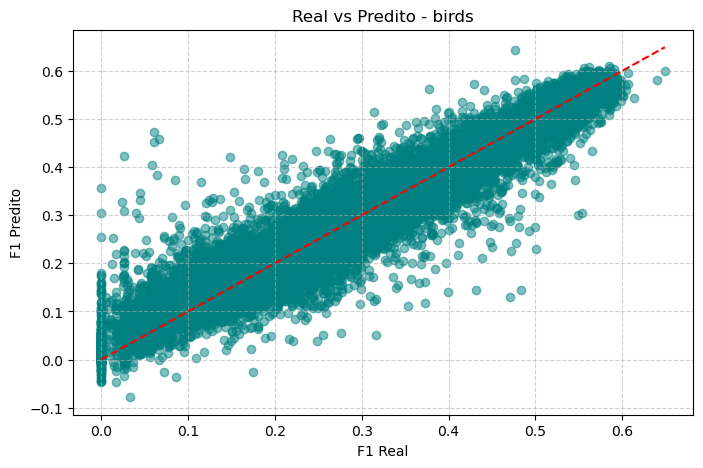

Resultados para o dataset: birds
Modelo usado: xgboost_multi_output
Spearman Global: 0.9760
Overlap no Top 2094 (Recall): 92.41%
Regret (Perda de F1): 0.0720


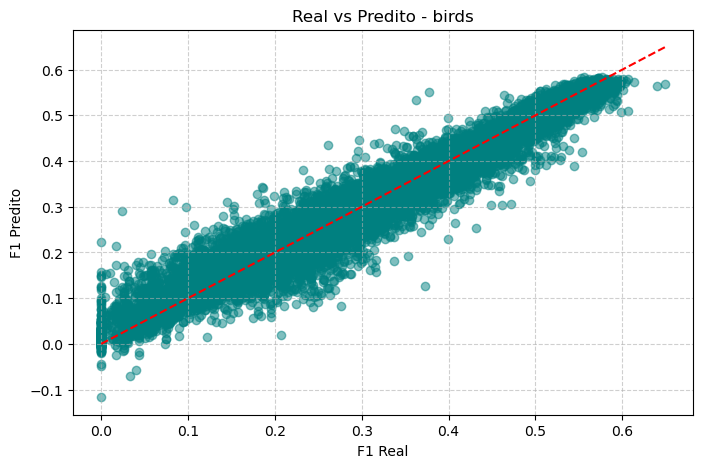

In [5]:
calculate_spearman(dataset="birds", model_name="mlp_native")
calculate_spearman(dataset="birds", model_name="xgboost_multi_output")
